In [1]:
print("Earthquake Project Started")

Earthquake Project Started


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex
import streamlit
import sqlalchemy
import requests
from datetime import datetime
import os
print("All libraries are working!")

All libraries are working!


#DATA RETRIVAL

In [3]:
#adding url
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

In [4]:
#created empty list anb setting the start and end year
all_records = []
start_year = datetime.now().year -5
end_year = datetime.now().year

In [5]:
for year in range(start_year, end_year + 1):

    for month in range(1, 13):

        start_date = f'{year}-{month:02d}-01'

        if month == 12:
            end_date = f'{year+1}-01-01'
        else:
            end_date = f'{year}-{month+1:02d}-01'

        params = {
            'format': 'geojson',
            'starttime': start_date,
            'endtime': end_date,
            'minmagnitude': 3
        }

        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f'failed for {start_date}')
            continue

        try:
            data = response.json()
        except Exception as e:
            print(f'json error for {start_date}: {e}')
            continue

        for f in data['features']:

            p = f['properties']
            g = f['geometry']['coordinates']

            all_records.append({
                'id': f.get('id'),
                'time': pd.to_datetime(p.get('time'), unit='ms'),
                'updated': pd.to_datetime(p.get('updated'), unit='ms'),
                'latitude': g[1] if g else None,
                'longitude': g[0] if g else None,
                'depth_km': g[2] if g else None,
                'mag': p.get('mag'),
                'magType': p.get('magType'),
                'place': p.get('place'),
                'status': p.get('status'),
                'tsunami': p.get('tsunami'),
                'sig': p.get('sig'),
                'net': p.get('net'),
                'nst': p.get('nst'),
                'dmin': p.get('dmin'),
                'rms': p.get('rms'),
                'gap': p.get('gap'),
                'types': p.get('types'),
                'ids': p.get('ids'),
                'sources': p.get('sources'),
                'type': p.get('type'),
                'magSource': p.get('magSource'),
                'locationSource': p.get('locationSource'),
                'magNst': p.get('magNst'),
                'depthError': p.get('depthError'),
                'magError': p.get('magError')
            })   

In [6]:
#added the retrived records in empty list
df = pd.DataFrame(all_records)


In [7]:
df.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type', 'magSource',
       'locationSource', 'magNst', 'depthError', 'magError'],
      dtype='object')

In [11]:
#checking row, columns and start, end time to make sure data imported correctly
df.to_csv("earthquake_raw_final.csv", index=False)

print("Final frozen dataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Min date:", df["time"].min())
print("Max date:", df["time"].max())


Final frozen dataset:
Rows: 120331
Columns: 26
Min date: 2021-01-01 00:14:07.580000
Max date: 2026-10-01 03:29:08.123000


In [12]:
df.to_csv("earthquake_raw_fixed.csv", index=False)

In [13]:
#checking null values
df.isna().sum()

id                     0
time                   0
updated                0
latitude               0
longitude              0
depth_km               0
mag                    0
magType                0
place                  0
status                 0
tsunami                0
sig                    0
net                    0
nst                27762
dmin                3978
rms                   19
gap                 3024
types                  0
ids                    0
sources                0
type                   0
magSource         120331
locationSource    120331
magNst            120331
depthError        120331
magError          120331
dtype: int64

In [14]:
df.describe()

,time,updated,latitude,longitude,depth_km,mag,tsunami,sig,nst,dmin,rms,gap
count,120331,120331,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000,92569.000000,116353.000000,120312.000000,117307.000000
mean,2023-11-18 16:52:51.481603840,2024-03-05 13:07:15.449625344,12.199091,8.011857,71.352471,4.256042,0.005568,287.468715,45.415128,3.191045,0.660508,122.824689
min,2021-01-01 00:14:07.580000,2021-01-01 10:15:32.601000,-84.493200,-179.999700,-3.740000,3.000000,0.000000,138.000000,0.000000,0.000000,0.000000,8.000000
25%,2022-05-22 07:16:15.598499840,2022-09-13 06:26:21.040000,-14.091650,-111.681300,10.000000,4.000000,0.000000,246.000000,20.000000,0.835000,0.490000,75.325000
50%,2023-11-26 18:16:26.400999936,2024-03-02 21:39:34.040000,14.669000,25.548800,21.000000,4.300000,0.000000,284.000000,32.000000,1.820000,0.650000,114.000000
75%,2025-06-06 21:30:52.093499904,2025-10-03 18:42:28.040000,39.153500,130.466150,70.561000,4.600000,0.000000,326.000000,56.000000,3.721000,0.830000,157.000000
max,2026-10-01 03:29:08.123000,2026-10-01 04:20:38.040000,87.375200,179.999400,683.578000,8.800000,1.000000,2910.000000,619.000000,62.558000,3.900000,359.000000
std,NaN,NaN,31.909871,129.043573,122.712831,0.610663,0.074411,91.815762,39.479549,4.461252,0.259652,62.836893


In [15]:
#checking dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120331 entries, 0 to 120330
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              120331 non-null  object        
 1   time            120331 non-null  datetime64[ns]
 2   updated         120331 non-null  datetime64[ns]
 3   latitude        120331 non-null  float64       
 4   longitude       120331 non-null  float64       
 5   depth_km        120331 non-null  float64       
 6   mag             120331 non-null  float64       
 7   magType         120331 non-null  object        
 8   place           120331 non-null  object        
 9   status          120331 non-null  object        
 10  tsunami         120331 non-null  int64         
 11  sig             120331 non-null  int64         
 12  net             120331 non-null  object        
 13  nst             92569 non-null   float64       
 14  dmin            116353 non-null  flo

In [16]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

CLEANING DATA

In [17]:
#creating new datafarme to clean the data 
df_new = df.copy()

In [18]:
print(df_new.shape)
print(df_new["time"].min())
print(df_new["time"].max())

(120331, 26)
2021-01-01 00:14:07.580000
2026-10-01 03:29:08.123000


In [19]:
print('cleaned: ',df_new.shape)
print('raw: ', df.shape)

cleaned:  (120331, 26)
raw:  (120331, 26)


In [20]:
month= df_new['time'].dt.month.value_counts().sort_index()
month

time
1     10578
2     10065
3     10928
4     10338
5      9762
6      9597
7     11843
8     11827
9      9611
10     8153
11     7954
12     9675
Name: count, dtype: int64

In [21]:
year= df_new['time'].dt.year.value_counts().sort_index()
year

time
2021    21926
2022    20208
2023    20830
2024    18659
2025    22824
2026    15884
Name: count, dtype: int64

In [22]:
#checking null values 
df_new.isna().sum()

id                     0
time                   0
updated                0
latitude               0
longitude              0
depth_km               0
mag                    0
magType                0
place                  0
status                 0
tsunami                0
sig                    0
net                    0
nst                27762
dmin                3978
rms                   19
gap                 3024
types                  0
ids                    0
sources                0
type                   0
magSource         120331
locationSource    120331
magNst            120331
depthError        120331
magError          120331
dtype: int64

In [23]:
#DROPPING THE EMPTY COLUMNS BECAUSE THEY WHERE 100% MISSING IN OUR COLLECTED API DATA
empty_columns = [
    'magSource',
    'locationSource',
    'magNst',
    'depthError',
    'magError'
]
df_new =  df_new.drop(columns= empty_columns)

In [24]:
df_new.columns

Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type'],
      dtype='object')

In [25]:
#ckecking the remaining columns count 
print('orignal_columns:',df.shape[1])
print('new_columns:',df_new.shape[1])

orignal_columns: 26
new_columns: 21


In [26]:
#CHECKING MISSING VALUES 
df_new.isnull().sum()

id               0
time             0
updated          0
latitude         0
longitude        0
depth_km         0
mag              0
magType          0
place            0
status           0
tsunami          0
sig              0
net              0
nst          27762
dmin          3978
rms             19
gap           3024
types            0
ids              0
sources          0
type             0
dtype: int64

#HANDLING THE MISSING COLUMNS WHICH HAS MISSING VALUES

In [27]:
#NST
df_new['nst'].dtype
df_new['nst'].describe()
df_new['nst'].isnull().sum()
print('DATA TYPES:' , df_new["nst"].dtype)
print('DESCRIBE :l' , df_new["nst"].describe())
print('MISSING VALUES:' , df_new["nst"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    92569.000000
mean        45.415128
std         39.479549
min          0.000000
25%         20.000000
50%         32.000000
75%         56.000000
max        619.000000
Name: nst, dtype: float64
MISSING VALUES: 27762


In [28]:
#checking outliers
Q1 = df_new["nst"].quantile(0.25)
Q3 = df_new["nst"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 20.0
Q3: 56.0
IQR: 36.0
Lower limit: -34.0
Upper limit: 110.0


In [29]:
#found outliers 
df_new[df_new["nst"] < lower].shape[0]
df_new[df_new["nst"] > upper].shape[0]
print('LOWER:' , df_new[df_new["nst"] < lower].shape[0])
print('UPPER:', df_new[df_new["nst"] > upper].shape[0])


LOWER: 0
UPPER: 6348


In [30]:
#filling values using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['nst'].median())
df_new["nst"] = df_new["nst"].fillna(df_new["nst"].median())

MEDIAN: 32.0


In [31]:
df_new['nst'].isna().sum()

np.int64(0)

In [32]:
#dmin
df_new['dmin'].dtype
df_new['dmin'].describe()
df_new['dmin'].isnull().sum()
print('DATA TYPES:' , df_new["dmin"].dtype)
print('DESCRIBE :l' , df_new["dmin"].describe())
print('MISSING VALUES:' , df_new["dmin"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    116353.000000
mean          3.191045
std           4.461252
min           0.000000
25%           0.835000
50%           1.820000
75%           3.721000
max          62.558000
Name: dmin, dtype: float64
MISSING VALUES: 3978


In [33]:
#checking outliers
Q1 = df_new["dmin"].quantile(0.25)
Q3 = df_new["dmin"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 0.835
Q3: 3.721
IQR: 2.886
Lower limit: -3.4940000000000007
Upper limit: 8.05


In [34]:
#found outliers 
df_new[df_new["dmin"] < lower].shape[0]
df_new[df_new["dmin"] > upper].shape[0]
print('LOWER:' , df_new[df_new["dmin"] < lower].shape[0])
print('UPPER:', df_new[df_new["dmin"] > upper].shape[0])

LOWER: 0
UPPER: 8584


In [35]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['dmin'].median())
df_new["dmin"] = df_new["dmin"].fillna(df_new["dmin"].median())

MEDIAN: 1.82


In [36]:
df_new['dmin'].isna().sum()

np.int64(0)

In [37]:
#rms
df_new['rms'].dtype
df_new['rms'].describe()
df_new['rms'].isnull().sum()
print('DATA TYPES:' , df_new["rms"].dtype)
print('DESCRIBE :l' , df_new["rms"].describe())
print('MISSING VALUES:' , df_new["rms"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    120312.000000
mean          0.660508
std           0.259652
min           0.000000
25%           0.490000
50%           0.650000
75%           0.830000
max           3.900000
Name: rms, dtype: float64
MISSING VALUES: 19


In [38]:
#checking outliers by using IQR
Q1 = df_new["rms"].quantile(0.25)
Q3 = df_new["rms"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 0.49
Q3: 0.83
IQR: 0.33999999999999997
Lower limit: -0.020000000000000018
Upper limit: 1.3399999999999999


In [39]:
#found outliers 
df_new[df_new["rms"] < lower].shape[0]
df_new[df_new["rms"] > upper].shape[0]
print('LOWER:' , df_new[df_new["rms"] < lower].shape[0])
print('UPPER:', df_new[df_new["rms"] > upper].shape[0])

LOWER: 0
UPPER: 627


In [40]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['rms'].median())
df_new["rms"] = df_new["rms"].fillna(df_new["rms"].median())

MEDIAN: 0.65


In [41]:
df_new['rms'].isna().sum()

np.int64(0)

In [42]:
#gap
df_new['gap'].dtype
df_new['gap'].describe()
df_new['gap'].isnull().sum()
print('DATA TYPES:' , df_new["gap"].dtype)
print('DESCRIBE :l' , df_new["gap"].describe())
print('MISSING VALUES:' , df_new["gap"].isnull().sum())

DATA TYPES: float64
DESCRIBE :l count    117307.000000
mean        122.824689
std          62.836893
min           8.000000
25%          75.325000
50%         114.000000
75%         157.000000
max         359.000000
Name: gap, dtype: float64
MISSING VALUES: 3024


In [43]:
#checking outliers by using IQR
Q1 = df_new["gap"].quantile(0.25)
Q3 = df_new["gap"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 75.325
Q3: 157.0
IQR: 81.675
Lower limit: -47.187499999999986
Upper limit: 279.5125


In [44]:
#found outliers 
df_new[df_new["gap"] < lower].shape[0]
df_new[df_new["gap"] > upper].shape[0]
print('LOWER:' , df_new[df_new["gap"] < lower].shape[0])
print('UPPER:', df_new[df_new["gap"] > upper].shape[0])

LOWER: 0
UPPER: 2737


In [45]:
#filled values by using median because column has outliers or a skewed distribution.
print('MEDIAN:' , df_new['gap'].median())
df_new["gap"] = df_new["gap"].fillna(df_new["gap"].median())

MEDIAN: 114.0


In [46]:
df_new['gap'].isna().sum()

np.int64(0)

In [47]:
df_new.isnull().sum()

id           0
time         0
updated      0
latitude     0
longitude    0
depth_km     0
mag          0
magType      0
place        0
status       0
tsunami      0
sig          0
net          0
nst          0
dmin         0
rms          0
gap          0
types        0
ids          0
sources      0
type         0
dtype: int64

#VALIDATING EACH COLUMN 

In [48]:
#Latitude
print('Empty:', df_new['latitude'].isna().sum())
print("Min:", df_new["latitude"].min())
print("Max:", df_new["latitude"].max())

print("Invalid latitude:",
      ((df_new["latitude"] < -90) | (df_new["latitude"] > 90)).sum())

Empty: 0
Min: -84.4932
Max: 87.3752
Invalid latitude: 0


In [49]:
#Longitude 
print('Empty:', df_new['longitude'].isna().sum())
print("Min:" , df_new["longitude"].min())
print("Max:", df_new["longitude"].max())
print("Invalid Longitude:", ((df_new["longitude"] < -180) | (df_new["longitude"] > 180)).sum())

Empty: 0
Min: -179.9997
Max: 179.9994
Invalid Longitude: 0


In [50]:
#depth_km
print('Empty:', df_new['depth_km'].isna().sum())
print("Min:" , df_new["depth_km"].min())
print("Max:", df_new["depth_km"].max())
print("Negative depth:", (df_new["depth_km"] < 0).sum())

Empty: 0
Min: -3.74
Max: 683.578
Negative depth: 119


In [51]:
#mag
print('Empty:', df_new['mag'].isna().sum())
print('Empty:', df_new['mag'].isna().sum())
print("Min:" , df_new["mag"].min())
print("Max:", df_new["mag"].max())

Empty: 0
Empty: 0
Min: 3.0
Max: 8.8


In [52]:
#nst
print('Empty:', df_new['nst'].isna().sum())
print(df_new["nst"].describe())
print("Negative NST:",(df_new["nst"] < 0).sum())
print("Zero NST:",(df_new["nst"] == 0).sum())

Empty: 0
count    120331.000000
mean         42.320075
std          35.085253
min           0.000000
25%          23.000000
50%          32.000000
75%          46.000000
max         619.000000
Name: nst, dtype: float64
Negative NST: 0
Zero NST: 8


In [54]:
#dmin
print('Empty:', df_new['dmin'].isna().sum())
print(df_new["dmin"].describe())
print("Negative dmin:", (df_new["dmin"] < 0).sum())

Empty: 0
count    120331.000000
mean          3.145720
std           4.393733
min           0.000000
25%           0.864000
50%           1.820000
75%           3.614000
max          62.558000
Name: dmin, dtype: float64
Negative dmin: 0


In [55]:
#gap
print('Empty:', df_new['gap'].isna().sum())
print(df_new["gap"].describe())
print("Negative gap:",(df_new["gap"] < 0).sum())

Empty: 0
count    120331.000000
mean        122.602919
std          62.057669
min           8.000000
25%          76.000000
50%         114.000000
75%         155.000000
max         359.000000
Name: gap, dtype: float64
Negative gap: 0


In [56]:
#sig
print('Empty:', df_new['sig'].isna().sum())
print(df_new["sig"].describe())
print("Negative sig:", (df_new["sig"] < 0).sum())

Empty: 0
count    120331.000000
mean        287.468715
std          91.815762
min         138.000000
25%         246.000000
50%         284.000000
75%         326.000000
max        2910.000000
Name: sig, dtype: float64
Negative sig: 0


In [57]:
#tsunami
print('Empty:', df_new['tsunami'].isna().sum())
print(df_new["tsunami"].value_counts())

Empty: 0
tsunami
0    119661
1       670
Name: count, dtype: int64


In [58]:
#status
print('Empty:', df_new['status'].isna().sum())
print(df_new["status"].value_counts())

Empty: 0
status
reviewed     120160
automatic       171
Name: count, dtype: int64


In [59]:
#type
print('Empty:', df_new['type'].isna().sum())
print(df_new["type"].value_counts(dropna=False))

Empty: 0
type
earthquake                119429
mining explosion             855
ice quake                     13
volcanic eruption             12
experimental explosion         5
other event                    5
landslide                      5
mine collapse                  3
quarry blast                   2
Landslide                      1
explosion                      1
Name: count, dtype: int64


In [60]:
df_new["type"] = df_new["type"].str.lower() #standardized
print('Empty:', df_new['type'].isna().sum())
print(df_new["type"].value_counts(dropna=False))

Empty: 0
type
earthquake                119429
mining explosion             855
ice quake                     13
volcanic eruption             12
landslide                      6
experimental explosion         5
other event                    5
mine collapse                  3
quarry blast                   2
explosion                      1
Name: count, dtype: int64


In [61]:
#magType
print('Empty:', df_new['magType'].isna().sum())
print(df_new["magType"].value_counts())

Empty: 0
magType
mb            85285
ml            17332
mww            7427
md             6554
mwr            2823
mw              683
mb_lg           127
ml(texnet)       43
mwb              32
mlr              10
mlv               5
ms_vx             4
mwc               2
ms_20             1
mlg               1
mwp               1
mh                1
Name: count, dtype: int64


In [62]:
#Date columns
print('Empty:', df_new['time'].isna().sum())
print(df_new["time"].dtype)
print(df_new["updated"].dtype)

print("Time range:")
print(df_new["time"].min())
print(df_new["time"].max())

print("Updated before event:",  (df_new["updated"] < df_new["time"]).sum())

Empty: 0
datetime64[ns]
datetime64[ns]
Time range:
2021-01-01 00:14:07.580000
2026-10-01 03:29:08.123000
Updated before event: 0


In [63]:
#id
print('Empty:', df_new['id'].isna().sum())
print('ID is unique:' , df_new["id"].is_unique)



Empty: 0
ID is unique: True


In [64]:
#net
print('Empty:', df_new['net'].isna().sum())
print(df_new["net"].value_counts())


Empty: 0
net
us        105235
pr          6541
ak          3864
tx          1039
nc          1001
hv           941
ci           913
nn           463
uu           116
ok            93
uw            60
nm            22
se            18
iscgem        16
av             6
ew             2
mb             1
Name: count, dtype: int64


In [65]:
#place
print('Empty:', df_new['place'].isna().sum())
print(df_new["place"].head(20))




Empty: 0
0           29 km SW of Villa Basilio Nievas, Argentina
1                                           Fiji region
2                       103 km SW of Basco, Philippines
3                               114 km N of M?n?b, Iran
4     184 km ENE of Olonkinbyen, Svalbard and Jan Mayen
5                    76 km NNE of Luquillo, Puerto Rico
6                    78 km NNE of Luquillo, Puerto Rico
7                       82 km N of Culebra, Puerto Rico
8                  99 km SE of Pondaguitan, Philippines
9                  69 km SE of Pondaguitan, Philippines
10                   75 km NNE of Luquillo, Puerto Rico
11                   76 km NNE of Luquillo, Puerto Rico
12                          52 km NE of Yairipok, India
13                  198 km SE of Sarangani, Philippines
14                          82 km SSE of Lethem, Guyana
15                         23 km ESE of Wright, Wyoming
16                   76 km NNE of Luquillo, Puerto Rico
17                   72 km NNE of Luqui

In [66]:
import regex as re
df_new["country"] = df_new["place"].str.extract(r",\s*([^,]+)$")
print(df_new[["place", "country"]].head(20))

                                                place                 country
0         29 km SW of Villa Basilio Nievas, Argentina               Argentina
1                                         Fiji region                     NaN
2                     103 km SW of Basco, Philippines             Philippines
3                             114 km N of M?n?b, Iran                    Iran
4   184 km ENE of Olonkinbyen, Svalbard and Jan Mayen  Svalbard and Jan Mayen
5                  76 km NNE of Luquillo, Puerto Rico             Puerto Rico
6                  78 km NNE of Luquillo, Puerto Rico             Puerto Rico
7                     82 km N of Culebra, Puerto Rico             Puerto Rico
8                99 km SE of Pondaguitan, Philippines             Philippines
9                69 km SE of Pondaguitan, Philippines             Philippines
10                 75 km NNE of Luquillo, Puerto Rico             Puerto Rico
11                 76 km NNE of Luquillo, Puerto Rico           

In [67]:
print("Country missing:", df_new["country"].isna().sum())

Country missing: 21691


In [68]:
df_new["place"].str.contains(",", regex=False).value_counts()

place
True     98640
False    21691
Name: count, dtype: int64

In [69]:
#show us the most common place formats that failed the Regex.
df_new.loc[df_new["country"].isna(), "place"].value_counts().head()

place
South Sandwich Islands region       3220
south of the Fiji Islands           2077
Kermadec Islands region             1994
Fiji region                         1360
southeast of the Loyalty Islands    1101
Name: count, dtype: int64

In [70]:
#types
print('Empty:', df_new['types'].isna().sum())
print(df_new["types"].head())


Empty: 0
0    ,dyfi,moment-tensor,origin,phase-data,
1                       ,origin,phase-data,
2                       ,origin,phase-data,
3                       ,origin,phase-data,
4                       ,origin,phase-data,
Name: types, dtype: object


In [71]:
df_new["types"] = df_new["types"].str.strip(",")
print(df_new["types"].head())

0    dyfi,moment-tensor,origin,phase-data
1                       origin,phase-data
2                       origin,phase-data
3                       origin,phase-data
4                       origin,phase-data
Name: types, dtype: object


In [72]:
#ids
print('Empty:', df_new['ids'].isna().sum())
df_new["ids"] = df_new['ids'].str.strip(",")
print(df_new["ids"].head())


Empty: 0
0    us6000ddi8
1    us6000dev6
2    us6000dev5
3    us6000ddhs
4    us6000dev4
Name: ids, dtype: object


In [73]:
#sources
print('Empty:', df_new['sources'].isna().sum())
df_new["sources"] = df_new['sources'].str.strip(",")
print(df_new["sources"].head())

Empty: 0
0    us
1    us
2    us
3    us
4    us
Name: sources, dtype: object


CHECKING THE ENTIRE DATA AFTER DATA CLEANING

In [75]:
print("Rows:", df_new.shape[0])
print("Columns:", df_new.shape[1])

print("\nDuplicate rows:")
print(df_new.duplicated().sum())

print("\nMissing values:")
print(df_new.isnull().sum())


print("\nData types:")
print(df_new.dtypes)

Rows: 120331
Columns: 22

Duplicate rows:
0

Missing values:
id               0
time             0
updated          0
latitude         0
longitude        0
depth_km         0
mag              0
magType          0
place            0
status           0
tsunami          0
sig              0
net              0
nst              0
dmin             0
rms              0
gap              0
types            0
ids              0
sources          0
type             0
country      21691
dtype: int64

Data types:
id                   object
time         datetime64[ns]
updated      datetime64[ns]
latitude            float64
longitude           float64
depth_km            float64
mag                 float64
magType              object
place                object
status               object
tsunami               int64
sig                   int64
net                  object
nst                 float64
dmin                float64
rms                 float64
gap                 float64
types              

In [76]:
df_new.drop(columns=["country"], inplace=True)

In [77]:
print("Rows:", df_new.shape[0])
print("Columns:", df_new.shape[1])

print("\nDuplicate rows:")
print(df_new.duplicated().sum())

print("\nMissing values:")
print(df_new.isnull().sum())


print("\nData types:")
print(df_new.dtypes)

Rows: 120331
Columns: 21

Duplicate rows:
0

Missing values:
id           0
time         0
updated      0
latitude     0
longitude    0
depth_km     0
mag          0
magType      0
place        0
status       0
tsunami      0
sig          0
net          0
nst          0
dmin         0
rms          0
gap          0
types        0
ids          0
sources      0
type         0
dtype: int64

Data types:
id                   object
time         datetime64[ns]
updated      datetime64[ns]
latitude            float64
longitude           float64
depth_km            float64
mag                 float64
magType              object
place                object
status               object
tsunami               int64
sig                   int64
net                  object
nst                 float64
dmin                float64
rms                 float64
gap                 float64
types                object
ids                  object
sources              object
type                 object
dtype: obj

In [78]:
df_new.describe()

,time,updated,latitude,longitude,depth_km,mag,tsunami,sig,nst,dmin,rms,gap
count,120331,120331,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000,120331.000000
mean,2023-11-18 16:52:51.481603840,2024-03-05 13:07:15.449625344,12.199091,8.011857,71.352471,4.256042,0.005568,287.468715,42.320075,3.145720,0.660507,122.602919
min,2021-01-01 00:14:07.580000,2021-01-01 10:15:32.601000,-84.493200,-179.999700,-3.740000,3.000000,0.000000,138.000000,0.000000,0.000000,0.000000,8.000000
25%,2022-05-22 07:16:15.598499840,2022-09-13 06:26:21.040000,-14.091650,-111.681300,10.000000,4.000000,0.000000,246.000000,23.000000,0.864000,0.490000,76.000000
50%,2023-11-26 18:16:26.400999936,2024-03-02 21:39:34.040000,14.669000,25.548800,21.000000,4.300000,0.000000,284.000000,32.000000,1.820000,0.650000,114.000000
75%,2025-06-06 21:30:52.093499904,2025-10-03 18:42:28.040000,39.153500,130.466150,70.561000,4.600000,0.000000,326.000000,46.000000,3.614000,0.830000,155.000000
max,2026-10-01 03:29:08.123000,2026-10-01 04:20:38.040000,87.375200,179.999400,683.578000,8.800000,1.000000,2910.000000,619.000000,62.558000,3.900000,359.000000
std,NaN,NaN,31.909871,129.043573,122.712831,0.610663,0.074411,91.815762,35.085253,4.393733,0.259632,62.057669


In [79]:
print("Shape:", df_new.shape)
print("Number of columns:", len(df_new.columns))

Shape: (120331, 21)
Number of columns: 21


In [80]:
print(df_new.columns.tolist())

['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag', 'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'rms', 'gap', 'types', 'ids', 'sources', 'type']


In [86]:
print(df_new.shape)
print(df_new.columns)

(120331, 21)
Index(['id', 'time', 'updated', 'latitude', 'longitude', 'depth_km', 'mag',
       'magType', 'place', 'status', 'tsunami', 'sig', 'net', 'nst', 'dmin',
       'rms', 'gap', 'types', 'ids', 'sources', 'type'],
      dtype='object')


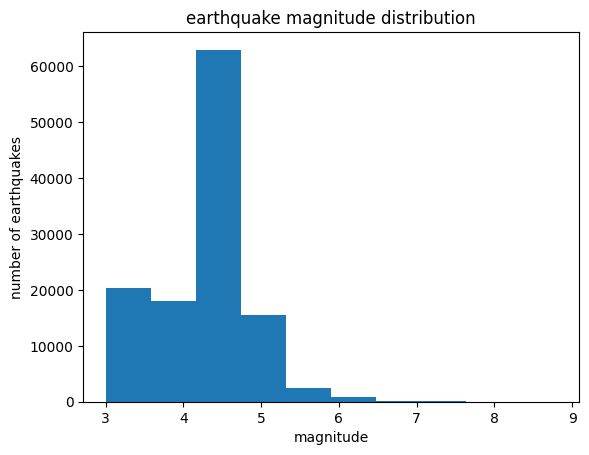

In [ ]:
import matplotlib.pyplot as plt

#Magnitude distribution
plt.hist(df['mag'], bins=10)
plt.xlabel('magnitude')
plt.ylabel('number of earthquakes')
plt.title('earthquake magnitude distribution')
plt.show()

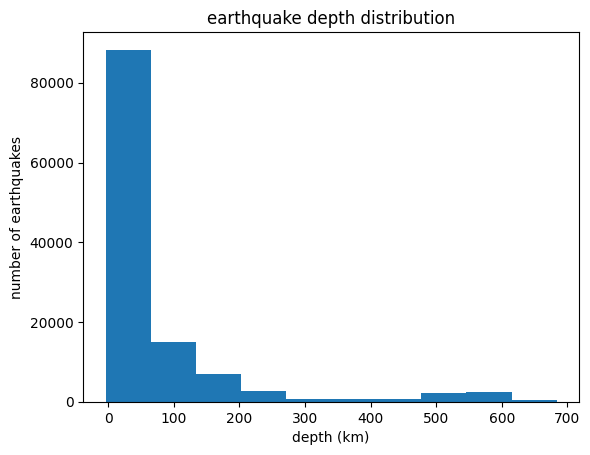

In [ ]:
#Depth distribution
plt.hist(df['depth_km'], bins=10)
plt.xlabel('depth (km)')
plt.ylabel('number of earthquakes')
plt.title('earthquake depth distribution')
plt.show()

In [ ]:
df['year'] = df['time'].dt.year
yearly_counts = df['year'].value_counts().sort_index()
yearly_counts

year
2021    21926
2022    20208
2023    20830
2024    18659
2025    22824
2026    15881
Name: count, dtype: int64

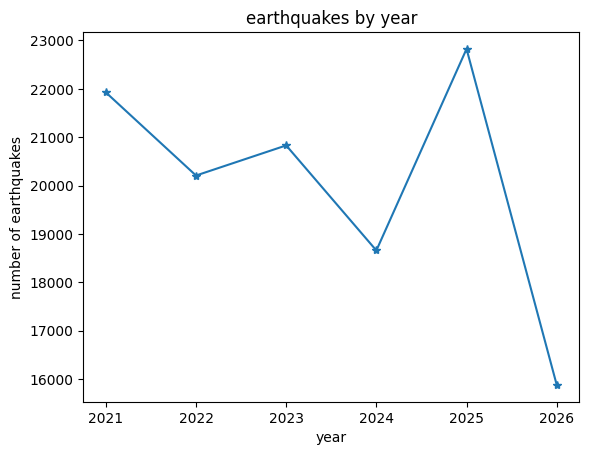

In [ ]:
#Earthquakes by year
plt.plot(yearly_counts.index, yearly_counts.values, marker='*')
plt.xlabel('year')
plt.ylabel('number of earthquakes')
plt.title('earthquakes by year')
plt.show()

In [ ]:
#Earthquakes by month
df["months"] = df['time'].dt.month_name()
month_order = ['January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']
monthly_counts = df['months'].value_counts().reindex(month_order)
monthly_counts

months
January      10578
February     10065
March        10928
April        10338
May           9762
June          9597
July         11843
August       11827
September     9609
October       8152
November      7954
December      9675
Name: count, dtype: int64

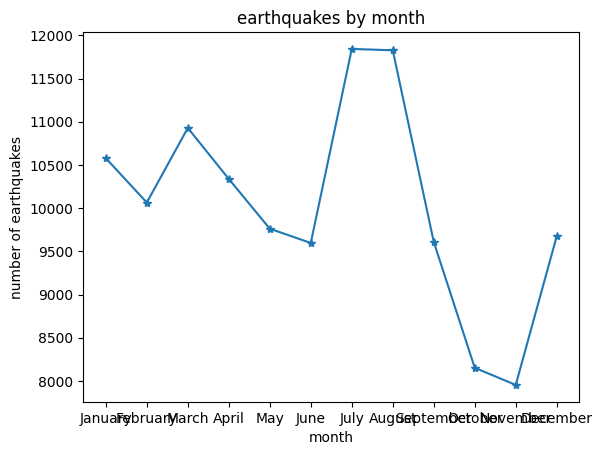

In [ ]:
#Earthquakes by month 
plt.plot(monthly_counts.index, monthly_counts.values, marker= '*')
plt.xlabel ('month')
plt.ylabel('number of earthquakes')
plt.title('earthquakes by month')
plt.show()

In [102]:
print(df_new.shape)

(120331, 21)


SQL insertion


In [ ]:
#Saving the data in csv file before insertion
#index=False means Pandas doesn't add the DataFrame index as an extra column.
df_new.to_csv("earthquake_cleaned.csv", index=False)


#make sure fikle was saved 
print(os.path.exists("earthquake_cleaned.csv"))




True
